# 🚗 Fuel Efficiency Prediction Model
## Vehicle Telematics — Regression Analysis v2

**Goal:** Predict fuel efficiency (kpl) from OBD sensor readings.

**Models compared:**
- Polynomial Ridge Regression — baseline, captures inverted-U speed/kpl curve
- Random Forest Regressor — tree-based, handles non-linearity and interactions
- CatBoost Regressor — gradient boosting optimized for categorical features

**Key engineered feature:** `est_gear` — gear position estimated via KMeans clustering on RPM/speed ratio, calibrated independently per vehicle. Not present in raw OBD data.

**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

## 0. Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

os.makedirs('../outputs', exist_ok=True)
print('Setup complete ✓')

Setup complete ✓


## 1. Load & Clean Data

In [15]:
df = pd.read_csv('../data/allcars.csv', low_memory=False)

numeric_cols = ['tripID','deviceID','gps_speed','battery','cTemp','dtc',
                'eLoad','iat','imap','kpl','maf','rpm','speed','tAdv','tPos']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['timeStamp'] = pd.to_datetime(df['timeStamp'], errors='coerce')
df = df.dropna(subset=['gps_speed','rpm','eLoad','kpl']).reset_index(drop=True)

# Range filters — remove sensor glitches
df = df[df['speed'].between(0, 150)]
df = df[df['eLoad'].between(0, 100)]
df = df[df['kpl'].between(0, 25)]
df = df[df['rpm'].between(0, 7000)]
if 'cTemp' in df.columns:
    df['cTemp'] = df['cTemp'].where(df['cTemp'].between(-10, 130), np.nan)

df = df.sort_values(['deviceID','tripID','timeStamp']).reset_index(drop=True)

# Exclude vehicles with no or unreliable KPL sensor data
kpl_by_device      = df.groupby('deviceID')['kpl'].sum()
NO_KPL_DEVICES     = kpl_by_device[kpl_by_device == 0].index.tolist()
UNRELIABLE_DEVICES = [7.0]
EXCLUDED           = NO_KPL_DEVICES + UNRELIABLE_DEVICES

df_model = df[
    (df['speed'] > 2) &
    (df['kpl'] > 0) &
    (~df['deviceID'].isin(EXCLUDED))
].copy()

print(f'Shape         : {df_model.shape}')
print(f'Excluded      : {[int(d) for d in EXCLUDED]}')
print(f'Vehicles used : {sorted(df_model["deviceID"].unique().astype(int).tolist())}')

Shape         : (1582926, 17)
Excluded      : [0, 1, 2, 4, 11, 14, 7]
Vehicles used : [3, 5, 6, 8, 9, 10, 12, 16]


## 2. Feature Engineering

| Feature | Description | Source |
|---|---|---|
| `est_gear` | Estimated gear via KMeans on RPM/speed ratio | **Engineered** |
| `rpm_per_speed` | Continuous gear ratio signal | **Engineered** |
| `power_proxy` | RPM × engine load — estimates power output | **Engineered** |
| `throttle_load` | Throttle × engine load — driving aggressiveness | **Engineered** |
| `speed_zone_ord` | Ordinal speed band (0–11) | **Engineered** |
| `speed`, `rpm`, `eLoad`, `tPos`, `cTemp` | Raw OBD sensor readings | Raw |

In [16]:
# --- Gear estimation: KMeans per vehicle ---
# OBD does not include a gear sensor.
# We estimate gear using RPM/speed ratio — higher ratio = lower gear.
# Each vehicle is clustered independently so different engine/transmission
# characteristics don't pollute each other's clusters.

df_model['gear_ratio'] = df_model['rpm'] / df_model['speed']

def estimate_gears_kmeans(vehicle_df, n_gears=6):
    ratios = vehicle_df['gear_ratio'].dropna().values.reshape(-1, 1)
    if len(ratios) < n_gears * 10:
        vehicle_df = vehicle_df.copy()
        vehicle_df['est_gear'] = 3
        return vehicle_df
    km = KMeans(n_clusters=n_gears, random_state=42, n_init=10)
    km.fit(ratios)
    # Highest centroid = gear 1 (high RPM, low speed)
    center_rank = {
        old: i + 1
        for i, old in enumerate(
            sorted(range(n_gears), key=lambda x: km.cluster_centers_[x], reverse=True)
        )
    }
    vehicle_df = vehicle_df.copy()
    vehicle_df['est_gear'] = [
        center_rank[c]
        for c in km.predict(vehicle_df['gear_ratio'].fillna(0).values.reshape(-1, 1))
    ]
    return vehicle_df

parts = []
for dev_id, vdf in df_model.groupby('deviceID'):
    parts.append(estimate_gears_kmeans(vdf))
df_model = pd.concat(parts).reset_index(drop=True)

# --- Additional engineered features ---
df_model['rpm_per_speed'] = df_model['rpm'] / (df_model['speed'] + 1)
df_model['power_proxy']   = df_model['rpm'] * df_model['eLoad'] / 100
df_model['throttle_load'] = df_model['tPos'] * df_model['eLoad'] / 100

bins   = [0,10,20,30,40,50,60,70,80,90,100,120,150]
labels = list(range(12))
df_model['speed_zone_ord'] = pd.cut(
    df_model['speed'], bins=bins, labels=labels, right=False
).astype(float)

if 'cTemp' in df_model.columns:
    df_model['cTemp'] = df_model['cTemp'].fillna(df_model['cTemp'].median())

print('Feature engineering complete ✓')

Feature engineering complete ✓


## 3. Prepare Features & Split

In [17]:
base_features = [
    'speed', 'rpm', 'eLoad', 'tPos', 'cTemp',
    'est_gear', 'speed_zone_ord',
    'rpm_per_speed', 'power_proxy', 'throttle_load'
]

X_base = df_model[base_features].fillna(0)

# Ridge & RF: one-hot encode deviceID
device_dummies = pd.get_dummies(df_model['deviceID'], prefix='vehicle').astype(int)
X_sklearn = pd.concat([
    X_base.reset_index(drop=True),
    device_dummies.reset_index(drop=True)
], axis=1)

# CatBoost: deviceID as native categorical (no encoding needed)
X_cat = X_base.copy()
X_cat['deviceID'] = df_model['deviceID'].astype(int).values
cat_feature_idx  = [X_cat.columns.get_loc('deviceID')]

y = df_model['kpl'].values

# Same indices for all models — fair comparison
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_sk_train,  X_sk_test  = X_sklearn.iloc[idx_train], X_sklearn.iloc[idx_test]
X_cat_train, X_cat_test = X_cat.iloc[idx_train],     X_cat.iloc[idx_test]
y_train,     y_test     = y[idx_train],               y[idx_test]

print(f'Train : {len(y_train):,}  |  Test : {len(y_test):,}')
print(f'sklearn features : {X_sklearn.shape[1]}')
print(f'CatBoost features: {X_cat.shape[1]} (deviceID handled natively)')

Train : 1,266,340  |  Test : 316,586
sklearn features : 18
CatBoost features: 11 (deviceID handled natively)


## 4. Model 1 — Polynomial Ridge (Baseline)
Speed vs KPL follows a concave curve — polynomial degree=2 captures the peak efficiency zone.

In [18]:
poly_ridge = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

poly_ridge.fit(X_sk_train, y_train)
y_pred_ridge = np.clip(poly_ridge.predict(X_sk_test), 0, None)

r2_ridge   = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)

print(f'Polynomial Ridge  →  R²: {r2_ridge:.4f}  RMSE: {rmse_ridge:.4f}  MAE: {mae_ridge:.4f}')

Polynomial Ridge  →  R²: 0.8285  RMSE: 1.9315  MAE: 1.2871


## 5. Model 2 — Random Forest

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    min_samples_leaf=5,
    max_features=0.5,   # 50% features per split — reduces tree correlation
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_sk_train, y_train)
y_pred_rf = rf_model.predict(X_sk_test)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print(f'Random Forest     →  R²: {r2_rf:.4f}  RMSE: {rmse_rf:.4f}  MAE: {mae_rf:.4f}')

Random Forest     →  R²: 0.9012  RMSE: 1.4661  MAE: 0.8700


## 6. Model 3 — CatBoost
`deviceID` passed as native categorical — CatBoost handles per-vehicle encoding internally without one-hot expansion.

In [20]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

cb_model.fit(
    X_cat_train, y_train,
    cat_features=cat_feature_idx,
    eval_set=(X_cat_test, y_test),
    early_stopping_rounds=50    # stop if no improvement for 50 rounds
)

y_pred_cb = cb_model.predict(X_cat_test)

r2_cb   = r2_score(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
mae_cb  = mean_absolute_error(y_test, y_pred_cb)

print(f'\nCatBoost          →  R²: {r2_cb:.4f}  RMSE: {rmse_cb:.4f}  MAE: {mae_cb:.4f}')

0:	learn: 4.5033797	test: 4.4981948	best: 4.4981948 (0)	total: 95.7ms	remaining: 1m 35s
200:	learn: 1.6386053	test: 1.6452063	best: 1.6452063 (200)	total: 13.9s	remaining: 55.3s
400:	learn: 1.5648008	test: 1.5732527	best: 1.5732527 (400)	total: 27.8s	remaining: 41.5s
600:	learn: 1.5341310	test: 1.5441955	best: 1.5441955 (600)	total: 41.8s	remaining: 27.8s
800:	learn: 1.5154849	test: 1.5273777	best: 1.5273777 (800)	total: 55.9s	remaining: 13.9s
999:	learn: 1.5025871	test: 1.5164777	best: 1.5164777 (999)	total: 1m 9s	remaining: 0us

bestTest = 1.516477748
bestIteration = 999


CatBoost          →  R²: 0.8943  RMSE: 1.5165  MAE: 0.9151


## 7. Model Comparison

In [21]:
results = pd.DataFrame({
    'Model' : ['Polynomial Ridge', 'Random Forest', 'CatBoost'],
    'R²'    : [r2_ridge,   r2_rf,   r2_cb],
    'RMSE'  : [rmse_ridge, rmse_rf, rmse_cb],
    'MAE'   : [mae_ridge,  mae_rf,  mae_cb]
}).round(4)

print(results.to_string(index=False))

best_idx        = results['R²'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
r2_best         = results.loc[best_idx, 'R²']

preds_map = {
    'Polynomial Ridge': y_pred_ridge,
    'Random Forest'   : y_pred_rf,
    'CatBoost'        : y_pred_cb
}
y_pred_best = preds_map[best_model_name]
print(f'\nBest model: {best_model_name}  (R² = {r2_best:.4f})')

           Model     R²   RMSE    MAE
Polynomial Ridge 0.8285 1.9315 1.2871
   Random Forest 0.9012 1.4661 0.8700
        CatBoost 0.8943 1.5165 0.9151

Best model: Random Forest  (R² = 0.9012)


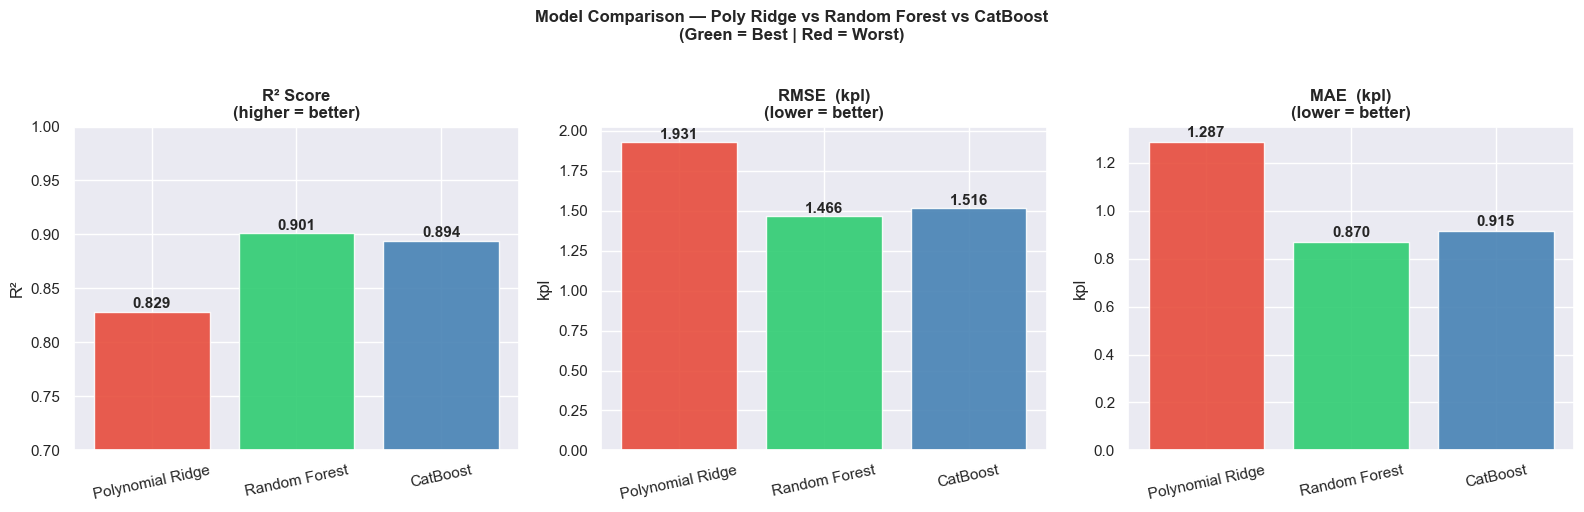

Saved -> outputs/06_model_comparison.png


In [22]:
# --- Visualization: 3-panel model comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results['Model'].tolist()

def bar_colors_higher(vals):
    return ['#2ecc71' if v == max(vals) else '#e74c3c' if v == min(vals) else 'steelblue' for v in vals]

def bar_colors_lower(vals):
    return ['#2ecc71' if v == min(vals) else '#e74c3c' if v == max(vals) else 'steelblue' for v in vals]

# R²
r2_vals = results['R²'].tolist()
axes[0].bar(models, r2_vals, color=bar_colors_higher(r2_vals), edgecolor='white', alpha=0.9)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('R² Score\n(higher = better)', fontweight='bold')
axes[0].set_ylabel('R²')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=12)

# RMSE
rmse_vals = results['RMSE'].tolist()
axes[1].bar(models, rmse_vals, color=bar_colors_lower(rmse_vals), edgecolor='white', alpha=0.9)
axes[1].set_title('RMSE  (kpl)\n(lower = better)', fontweight='bold')
axes[1].set_ylabel('kpl')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[1].tick_params(axis='x', rotation=12)

# MAE
mae_vals = results['MAE'].tolist()
axes[2].bar(models, mae_vals, color=bar_colors_lower(mae_vals), edgecolor='white', alpha=0.9)
axes[2].set_title('MAE  (kpl)\n(lower = better)', fontweight='bold')
axes[2].set_ylabel('kpl')
for i, v in enumerate(mae_vals):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[2].tick_params(axis='x', rotation=12)

plt.suptitle('Model Comparison — Poly Ridge vs Random Forest vs CatBoost\n(Green = Best | Red = Worst)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/06_model_comparison.png')

## 8. Predicted vs Actual — Best Model

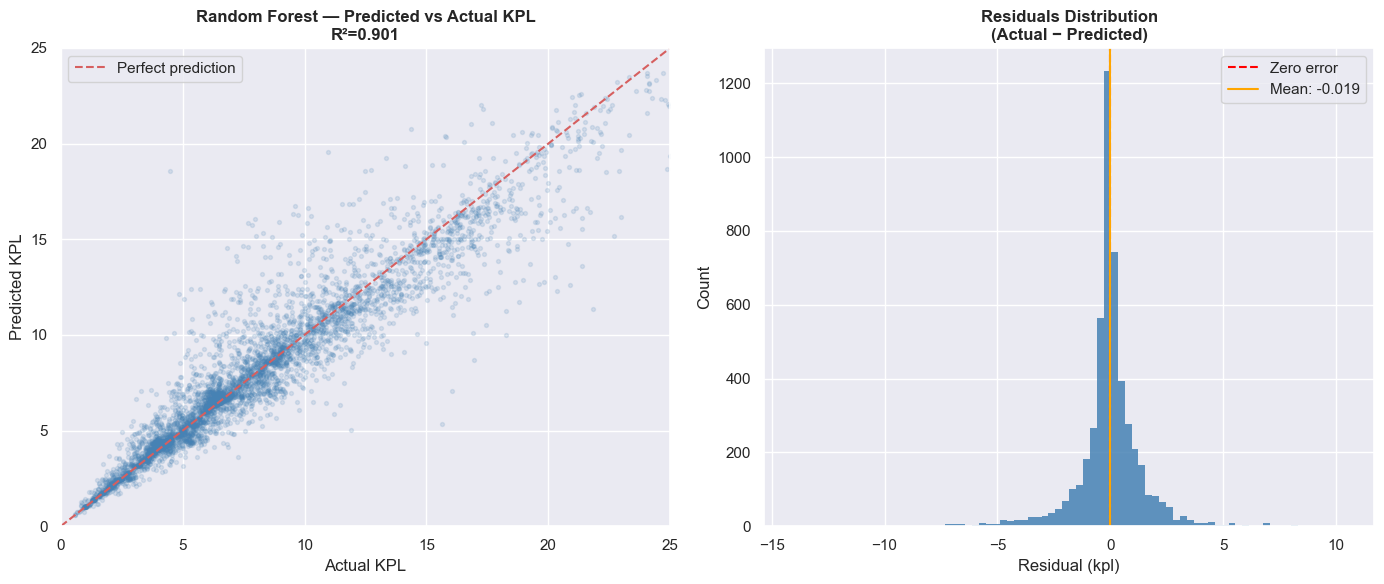

Saved -> outputs/07_predicted_vs_actual.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample_idx = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
y_test_s   = y_test[sample_idx]
y_pred_s   = y_pred_best[sample_idx]

# Scatter
axes[0].scatter(y_test_s, y_pred_s, alpha=0.15, s=8, color='steelblue')
axes[0].plot([0,25],[0,25], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim([0,25])
axes[0].set_ylim([0,25])
axes[0].set_title(f'{best_model_name} — Predicted vs Actual KPL\nR²={r2_best:.3f}',
                  fontweight='bold')
axes[0].set_xlabel('Actual KPL')
axes[0].set_ylabel('Predicted KPL')
axes[0].legend()

# Residuals
residuals = y_test_s - y_pred_s
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='-', lw=1.5,
                label=f'Mean: {residuals.mean():.3f}')
axes[1].set_title('Residuals Distribution\n(Actual − Predicted)', fontweight='bold')
axes[1].set_xlabel('Residual (kpl)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/07_predicted_vs_actual.png')

## 9. Per-Vehicle Predicted vs Actual

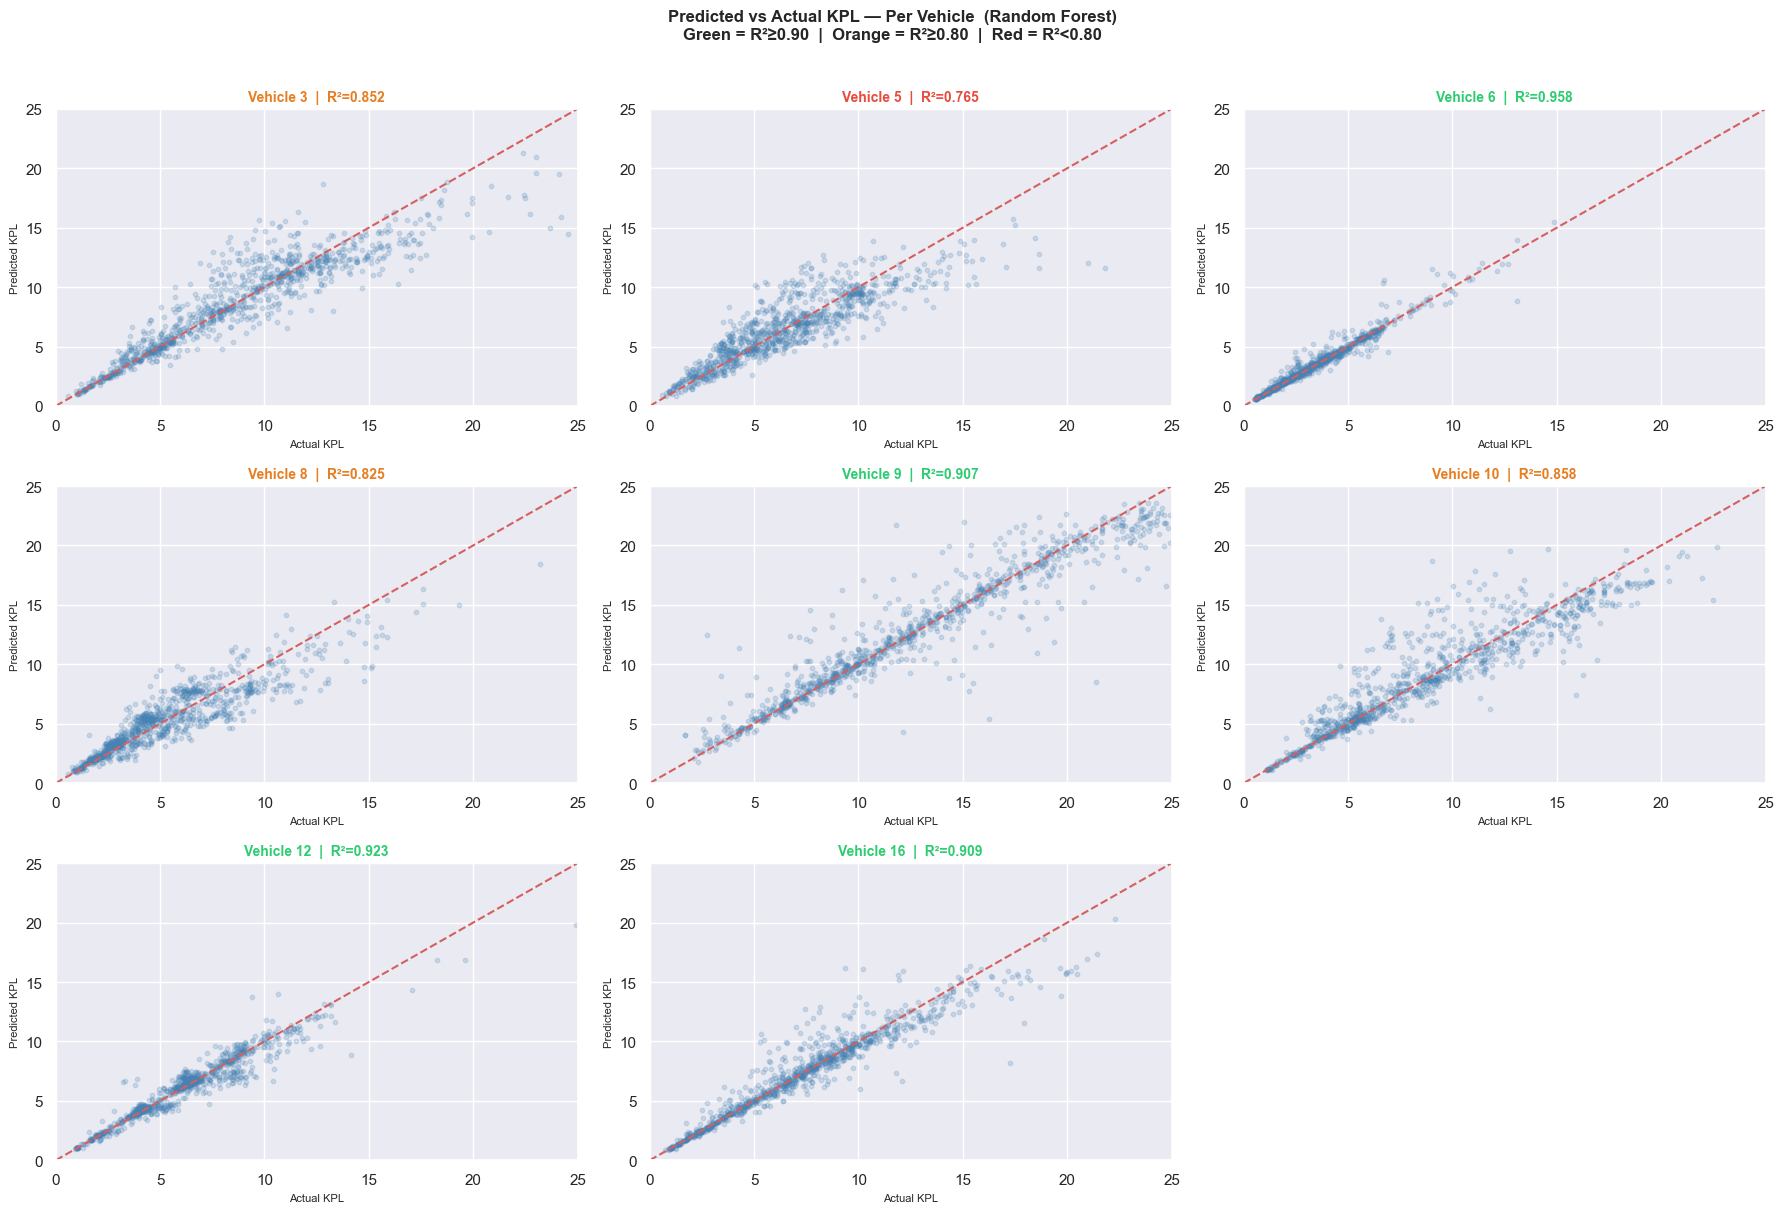

Saved -> outputs/08_per_vehicle_predictions.png


In [24]:
df_test              = X_cat_test.copy()
df_test['actual']    = y_test
df_test['predicted'] = y_pred_best

devices = sorted(df_test['deviceID'].unique())
n_cols  = 3
n_rows  = -(-len(devices) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices):
    ax     = axes[i]
    subset = df_test[df_test['deviceID'] == dev_id].sample(
        min(1000, (df_test['deviceID'] == dev_id).sum()), random_state=42
    )
    r2_dev = r2_score(subset['actual'], subset['predicted'])

    # Color code by performance
    title_color = '#2ecc71' if r2_dev >= 0.90 else '#e67e22' if r2_dev >= 0.80 else '#e74c3c'

    ax.scatter(subset['actual'], subset['predicted'], alpha=0.2, s=10, color='steelblue')
    ax.plot([0,25],[0,25], 'r--', lw=1.5)
    ax.set_xlim([0,25])
    ax.set_ylim([0,25])
    ax.set_title(f'Vehicle {int(dev_id)}  |  R²={r2_dev:.3f}',
                 fontweight='bold', fontsize=10, color=title_color)
    ax.set_xlabel('Actual KPL', fontsize=8)
    ax.set_ylabel('Predicted KPL', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f'Predicted vs Actual KPL — Per Vehicle  ({best_model_name})\n'
    'Green = R²≥0.90  |  Orange = R²≥0.80  |  Red = R²<0.80',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/08_per_vehicle_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/08_per_vehicle_predictions.png')

## 10. Feature Importance — CatBoost vs Random Forest

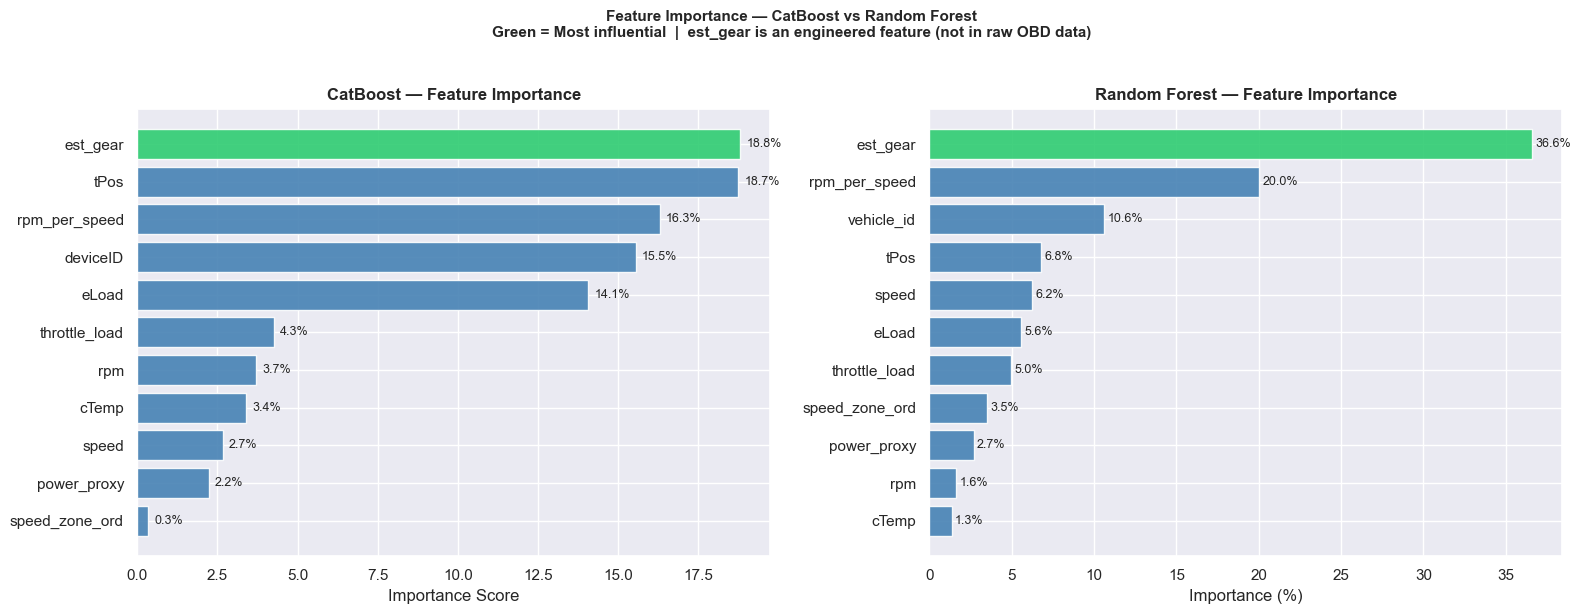

Saved -> outputs/09_feature_importance.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CatBoost importance
cb_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=X_cat.columns
).sort_values(ascending=True)

colors_cb = ['#2ecc71' if v == cb_imp.max() else 'steelblue' for v in cb_imp.values]
axes[0].barh(cb_imp.index, cb_imp.values, color=colors_cb, edgecolor='white', alpha=0.9)
axes[0].set_title('CatBoost — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(cb_imp.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Random Forest importance (collapse vehicle dummies)
vehicle_cols = [c for c in X_sklearn.columns if c.startswith('vehicle_')]
rf_imp       = pd.Series(rf_model.feature_importances_, index=X_sklearn.columns)
rf_imp_clean = rf_imp.drop(vehicle_cols)
rf_imp_clean['vehicle_id'] = rf_imp[vehicle_cols].sum()
rf_imp_clean = rf_imp_clean.sort_values(ascending=True)

colors_rf = ['#2ecc71' if v == rf_imp_clean.max() else 'steelblue' for v in rf_imp_clean.values]
axes[1].barh(rf_imp_clean.index, rf_imp_clean.values * 100,
             color=colors_rf, edgecolor='white', alpha=0.9)
axes[1].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance (%)')
for i, v in enumerate(rf_imp_clean.values * 100):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle(
    'Feature Importance — CatBoost vs Random Forest\n'
    'Green = Most influential  |  est_gear is an engineered feature (not in raw OBD data)',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/09_feature_importance.png')

## 11. Key Findings

In [26]:
top_cb = cb_imp.idxmax()

print('=' * 65)
print('  MODEL COMPARISON')
print('=' * 65)
print(results.to_string(index=False))
print(f'\n  Best model : {best_model_name}  (R² = {r2_best:.4f})')
print()
print('  CATBOOST FEATURE IMPORTANCE')
print('=' * 65)
for feat, imp in cb_imp.sort_values(ascending=False).items():
    marker = '  ← engineered (not in raw OBD)' if feat == 'est_gear' else ''
    print(f'  {feat:<22} {imp:5.1f}%{marker}')
print('=' * 65)

  MODEL COMPARISON
           Model     R²   RMSE    MAE
Polynomial Ridge 0.8285 1.9315 1.2871
   Random Forest 0.9012 1.4661 0.8700
        CatBoost 0.8943 1.5165 0.9151

  Best model : Random Forest  (R² = 0.9012)

  CATBOOST FEATURE IMPORTANCE
  est_gear                18.8%  ← engineered (not in raw OBD)
  tPos                    18.7%
  rpm_per_speed           16.3%
  deviceID                15.5%
  eLoad                   14.1%
  throttle_load            4.3%
  rpm                      3.7%
  cTemp                    3.4%
  speed                    2.7%
  power_proxy              2.2%
  speed_zone_ord           0.3%
